Tarefa: Classificar Homer e Bart com rede neural convolucional
Olá!

Na tarefa anterior você desenvolveu uma rede neural densa para classificar os personagens utilizando a abordagem de extração de características. A ideia agora é usar as imagens do Homer e do Bart assim como fizemos nas aulas sobre a classificação dos gatos e cachorros, comparando as duas abordagens. Siga as seguintes instruções:

Você pode fazer o download das imagens do Homer e do Bart, as quais já estão separadas nas respectivas pastas de treinamento e teste (75% para treinamento e 25% para teste)

Como essa base de dados possui poucas imagens, utilize os recursos de Data Augmentation para gerar mais amostrar

Abaixo você encontra a solução

In [18]:
# ambiente anaconda
import sys
print(sys.executable) # orange3 ou youtube

/home/fabiene/anaconda3/envs/orange3/bin/python


In [19]:
import sys
print(sys.version)

3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]


# Tarefa: Homer e Bart com Redes Neurais Convolucionais

## Etapa 1: Importação das bibliotecas

In [20]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
import zipfile
torch.__version__

'2.9.1+cpu'

In [21]:
torch.manual_seed(123) # semente

## Etapa 2: Construção do modelo

Rede Neural Convolucional (CNN): Diferente da anterior, esta é especialista em visão computacional, pois usa camadas que conseguem "enxergar" formas, bordas e texturas em imagens.

In [22]:
# nn.Sequential: Define a arquitetura da CNN como uma sequência de camadas.
# output = (input - filter + 1) / stride
# a nossa imagem definimos abaixo como 64x64 pixels no transform_train, tanto para o treino como para o teste
# 1. Redimensiona a imagem para 64x64 pixels (necessário para entrar na sua rede)
#transforms.Resize([64, 64]),

classificador = nn.Sequential(
    
    # 1. PRIMEIRA CONVOLUÇÃO:
    # in_channels=3: Recebe a imagem colorida (RGB).
    # out_channels=32: Cria 32 'filtros' diferentes para detectar características (bordas, curvas).
    # kernel_size=3: Cada filtro tem o tamanho de 3x3 pixels.
    nn.Conv2d(in_channels = 3, out_channels = 32, kernel_size = 3),
    nn.ReLU(), # Ativação para manter apenas os padrões importantes (valores > 0).

    # stride é de quantos em quantos o pixels vai andando, no caso 1
    ## output = (input - filter + 1) / stride 
    # (64 - 3 + 1) / 1 = 62x62    
    # 2. POOLING (Redução):
    # Diminui o tamanho da imagem pela metade (ex: de 64x64 para 32x32),
    # mantendo apenas as características mais fortes e economizando processamento.
    # 2. POOLING: Reduz a dimensão espacial pela metade (62 / 2 = 31)
    nn.MaxPool2d(kernel_size = 2),

    # 3. SEGUNDA CONVOLUÇÃO:
    # Recebe os 32 mapas da camada anterior e aplica mais 32 filtros para detectar 
    # formas mais complexas (como formatos de olhos ou orelhas).
    # 3. CONVOLUÇÃO: Recebe 32, solta 32. Kernel 3x3 reduz mais 2 pixels (31-3+1 = 29)
    # 31x31
    nn.Conv2d(32, 32, 3),
    ## output = (input_novo - filter + 1) / stride 
    # (31 - 3 + 1) / 1 = 29x29
    nn.ReLU(),
    # 4. POOLING: Reduz novamente (29 / 2 = 14.5 -> Arredonda para 14)
   # tamanho o filtro também será 2x2 (tamanho da matriz)
    nn.MaxPool2d(2), # Reduz novamente o tamanho da imagem.

    # 4. FLATTEN (Achatamento):
    # Transforma os mapas de bits (matrizes) em um único vetor longo (linha reta).
    # É a ponte necessária para sair da parte visual e ir para a parte lógica.
    nn.Flatten(),
    # 14*14*32=6272 neurônios de entrada-> 4 -> 4 -> 1
    # neurônio das camadas ocultas => 6 colunas + 1 final /2 = 4

    # 5. CAMADAS DENSAS (Rede Neural Comum):
    # in_features = 14*14*32: Recebe o vetor resultante das convoluções.
    # Conecta as características visuais para tomar a decisão final.
    nn.Linear(in_features = 14*14*32, out_features = 4),
    nn.ReLU(),
    
    # Camada intermediária para refinar o raciocínio.
    nn.Linear(4, 4),
    nn.ReLU(),

    # 6. CAMADA DE SAÍDA:
    # Reduz para 1 neurônio final.
    nn.Linear(4, 1),
    # Transforma o resultado em uma probabilidade entre 0 e 1 (binário).
    nn.Sigmoid()
)

$\begin{array}{|c|c|c|c|}
\hline
\textbf{Função} & \textbf{Fórmula} & \textbf{Intervalo de saída} & \textbf{Uso comum} \\
\hline
\text{Sigmoid} & 
\sigma(x) = \frac{1}{1 + e^{-x}} & (0, 1) & \text{Classificação binária} \\
\hline
\text{Tanh} & 
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} & (-1, 1) & \text{Camadas ocultas (alternativa ao ReLU)} \\
\hline
\text{ReLU} & 
f(x) = \max(0, x) & [0, \infty) & \text{Camadas ocultas (mais usado)} \\
\hline
\text{Leaky ReLU} & 
f(x) = \begin{cases}
x & \text{se } x > 0 \\
\alpha x & \text{se } x \leq 0
\end{cases} & (-\infty, \infty) & \text{Evita neurônios mortos no ReLU} \\
\hline
\text{ELU} & 
f(x) = \begin{cases}
x & \text{se } x > 0 \\
\alpha(e^x - 1) & \text{se } x \leq 0
\end{cases} & (-\alpha, \infty) & \text{Camadas ocultas, alternativa ao ReLU} \\
\hline
\text{Softmax} & 
f(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}} & (0, 1), \ \sum f(x_i) = 1 & \text{Classificação multiclasse} \\
\hline
\end{array}$

# 🔹 O ReLU (Rectified Linear Unit)

Características:

Simples, rápido de calcular.

Resolve o problema do vanishing gradient (quando os gradientes ficam quase zero em sigmoides/tanh).

Muito usado em camadas ocultas.

⚠️ Problema: pode causar “neurônios mortos” (quando muitos valores ficam ≤ 0 e nunca mais reativam).


# 🔹 1. Sigmoid

Saída entre 0 e 1 → ideal para classificação binária.

Problema: saturação → gradientes muito pequenos para valores extremos.

# 🔹 2. Tanh (Tangente Hiperbólica)

Saída entre -1 e 1.

Centraliza os dados em torno de 0 (melhor que sigmoid).

Mas ainda sofre com vanishing gradient.

# 🔹 3. Leaky ReLU

Variante do ReLU que deixa um “vazamento” para valores negativos.

Resolve o problema de neurônios mortos.

#🔹 4. ELU (Exponential Linear Unit)

Parecido com ReLU, mas valores negativos seguem uma curva exponencial suave.
Melhora a aprendizagem, mas é mais caro computacionalmente.

#🔹 5. Softmax

Transforma um vetor de valores em probabilidades que somam 1.

Usado em classificação multiclasse (saída com várias categorias).



🔹 Resumo, o uso mais comum:

Camadas ocultas → ReLU, Leaky ReLU, às vezes Tanh/ELU.

Saída binária → Sigmoid.

Saída multiclasse → Softmax.



### valores numéricos de séries temporais (ex: vendas, demanda, preços), o ideal é:

- ReLU nas camadas ocultas

- Linear (sem ativação) na saída.

### valores numéricos de séries temporais (ex: vendas, demanda, preços), o ideal é:

- ReLU nas camadas ocultas

- Linear (sem ativação) na saída.

In [23]:
# 1. criterion (Critério de Erro): Define a função de perda (Loss Function).
# BCELoss (Binary Cross Entropy Loss): É a medida de erro padrão para classificação binária (0 ou 1).
# Ela calcula a "distância" entre a previsão da rede (ex: 0.7) e a resposta real (ex: 1.0).
# Quanto maior essa distância, maior o erro que a rede precisa corrigir.
criterion = nn.BCELoss()

# 2. optimizer (Otimizador): É o algoritmo que ajusta os pesos da rede.
# optim.Adam: Um dos otimizadores mais modernos e eficientes. Ele ajusta a "velocidade" 
# do aprendizado automaticamente para cada neurônio.
# classificador.parameters(): Informa ao Adam quais são os pesos e conexões da rede
# que ele tem permissão para alterar durante o treino.
optimizer = optim.Adam(classificador.parameters())

## Etapa 3: Base de dados

In [24]:
# from google.colab import drive
# drive.mount('/content/gdrive')

In [25]:
path = 'dataset_personagens.zip'
zip_object = zipfile.ZipFile(file = path, mode = 'r')
zip_object.extractall('./')
zip_object.close()

In [30]:
data_dir_train = 'dataset_personagens/training_set/'
data_dir_test = 'dataset_personagens/test_set/'

In [31]:
# criar um tranformador para a base de dados de treinamento
# leitura dos dados e fazer o treinamento

transform_train = transforms.Compose( # Agrupa várias transformações em uma única "receita"
    [
     # 1. Redimensiona a imagem para 64x64 pixels (necessário para entrar na sua rede)
     transforms.Resize([64, 64]),
     
     # 2. Inverte a imagem horizontalmente de forma aleatória (como um espelho)
     # Ajuda a rede a entender que um gato virado para a esquerda ainda é um homer.
     transforms.RandomHorizontalFlip(),
     
     # 3. Aplica distorções matemáticas (Afim):
     # degrees=7: Gira a imagem em até 7 graus. (rotacionar a imagem
     # translate: Move a imagem levemente para os lados ou para cima/baixo. (rotação na imagem)
     # shear: Inclina a imagem (deforma os ângulos). 
     # scale: Dá um zoom de até 20% (1.2) na imagem. (escala do zoom)
     transforms.RandomAffine(degrees=7,
                             translate=(0, 0.07),
                             shear=0.2, 
                             scale=(1, 1.2)),
     
     # 4. Transforma a imagem PIL (pixels 0-255) em um Tensor do PyTorch (0.0 a 1.0)
     transforms.ToTensor()
    ]
)

In [32]:
# transformador na base de teste

transform_test = transforms.Compose( # Agrupa os passos de preparação para as imagens de teste
    [
     # 1. Ajusta o tamanho da imagem para 64x64 pixels.
     # Todas as imagens que entrarem na rede precisam ter o mesmo tamanho do treino.
     transforms.Resize([64, 64]),

     # 2. Converte a imagem (que está em formato PIL/Pixels) para um Tensor do PyTorch.
     # Também muda a escala de cores de 0-255 para 0.0-1.0.
     transforms.ToTensor()
    ]
)

In [34]:
# criação da base de dados, leitura da imagem ImageFolder
# leitura das imagens e fazer as transformações
# ImageFolder: Cria o dataset mapeando automaticamente as pastas como classes (ex: 'homer' e 'bart')
# data_dir_train: O caminho no computador onde as pastas estão (/.../test_set/)
# transform: Aplica aquela "receita" de distorções (Resize, Flip, etc.) que definimos antes
train_dataset = datasets.ImageFolder(data_dir_train, 
                                     transform=transform_train
                                    )

In [35]:
train_dataset

Dataset ImageFolder
    Number of datapoints: 196
    Root location: dataset_personagens/training_set/
    StandardTransform
Transform: Compose(
               Resize(size=[64, 64], interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               RandomAffine(degrees=[-7.0, 7.0], translate=(0, 0.07), scale=(1, 1.2), shear=[-0.2, 0.2])
               ToTensor()
           )

In [36]:
# Dataset ImageFolder # imagem
    
# Number of datapoints: 196 # número dos registros

# transformações que vai fazer: StandardTransform

# fazendo a normalização, trocar pixels por  valores entre 0 e 1

In [37]:
# treinamento de 32 a 32 registros, 
# shuffle true para misturar bem os dados

# DataLoader é quem organiza a entrega dessas imagens para o modelo durante o treinamento.
# DataLoader: Gerencia como os dados serão entregues ao modelo durante o treino
train_loader = torch.utils.data.DataLoader(
    train_dataset,    # O dataset que criamos com o ImageFolder
    batch_size = 10,  # Divide os dados em grupos de 10 imagens por vez
    shuffle = True    # Embaralha as imagens a cada nova época (ciclo de treino)
)

In [38]:
test_dataset = datasets.ImageFolder(data_dir_test,
                                    transform=transform_test)

In [39]:

test_loader = torch.utils.data.DataLoader(test_dataset,
                                          batch_size = 10,
                                          shuffle=True)

## Etapa 4: Treinamento e avaliação

In [40]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device

device(type='cpu')

In [41]:
classificador.to(device)

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=6272, out_features=4, bias=True)
  (8): ReLU()
  (9): Linear(in_features=4, out_features=4, bias=True)
  (10): ReLU()
  (11): Linear(in_features=4, out_features=1, bias=True)
  (12): Sigmoid()
)

In [42]:
def training_loop(loader, epoch):
    # Inicializam os acumuladores para calcular a média no final da época
    running_loss = 0. # Soma das perdas (erro)
    running_accuracy = 0. # Soma da acurácia (acertos)

    # 'loader' divide os dados em pacotes (batches). 'enumerate' conta os loops.
    for i, data in enumerate(loader):
        # inputs pixels das imagens , e as respostas labels
        inputs, labels = data # Separa entrada (X) e resposta real (y)
        
        # Envia os dados para a GPU (se disponível) ou CPU (device)
        inputs, labels = inputs.to(device), labels.to(device)
        
        # 1. Zera a memória de gradientes anteriores (limpa o cache do erro anterior)
        # zerar os gradientes 
        # O gradiente é a direção para onde devemos ajustar os pesos para diminuir o erro.
        # optimizer.zero_grad() limpa os cálculos anteriores para não misturar erros novos com velhos.
        optimizer.zero_grad()
        
        # 2. Forward: O modelo faz a previsão baseada nos inputs atuais
        # classificar
        # retorna se é gato ou cachorro, um valor apenas
        # (15): Linear(in_features=128, out_features=1, bias=True)
        outputs = classificador(inputs)

        # 3. Calcula o erro (Loss) comparando o palpite (outputs) com a realidade (labels)
        # calculamos os erros, labels float => a função que calcula o loss BC(Binaru Cross) exige valores float
        loss = criterion(outputs, labels.float().view(*outputs.shape))

        # Acumula o valor do erro para o relatório final
        running_loss += loss.item()
        # 4. Backward (Backpropagation): Calcula quanto cada 'neurônio' errou
        loss.backward()       
        # 5. Step: O otimizador atualiza os pesos da rede para errar menos na próxima
        optimizer.step()
        # Transforma a probabilidade (0 a 1) em classe binária: 1 se > 0.5, senão 0
        # for interno de classificações de 0 e 1, percorrendo a lista de outputs
        predicted = torch.tensor([1 if output > 0.5 else 0 for output in outputs]).to(device)

                # Verifica onde o modelo acertou (True) ou errou (False)
        # verificar se o previsor é igual ao dado real, e view é para deixar no mesmo formato que a previsão
        equals = predicted == labels.view(*predicted.shape)
        
        # Transforma os True/False em 1/0 e tira a média (ex: 0.85 de acurácia)
        # calcula a média da acurácia
        accuracy = torch.mean(equals.float())
        running_accuracy += accuracy
        # Imprime o progresso em tempo real na mesma linha (\r)
        # Imprimindo os dados referentes a esse loop
        print('\rÉPOCA {:3d} - Loop {:3d} de {:3d}: perda {:03.2f} - precisão {:03.2f}'.format(epoch + 1, i + 1,
                                                                                               len(loader), 
                                                                                               loss, accuracy), end = '\r')
    # Ao final de todos os pacotes, imprime a média de erro e acerto da época inteira
    # Imprimindo os dados referentes a essa época
    print('\rÉPOCA {:3d} FINALIZADA: perda {:.5f} - precisão {:.5f}'.format(epoch + 1, running_loss/len(loader),
                    running_accuracy/len(loader)))

In [43]:
# Inicia um ciclo de 100 épocas (a rede verá todo o conjunto de dados 100 vezes)
for epoch in range(100):
    print('Treinando...') #treinando
    # 1. FASE DE APRENDIZADO   
    # Executa o loop de treino usando o carregador de dados de treinamento
    training_loop(train_loader, epoch)
    
    # modo de avaliação no treino, em modo de acurácia
    # 2. PREPARAÇÃO PARA TESTE
    # Coloca o modelo em modo de avaliação (eval). 
    # Isso desativa coisas como Dropout, garantindo previsões estáveis.    
    classificador.eval()
    
    print('Validando...') # testando, época a época
    # 3. FASE DE VALIDAÇÃO
    # Usa a mesma função, mas agora com os dados de teste para ver como a rede lida com o que é novo    
    training_loop(test_loader, epoch)
    # 4. RETORNO AO TRABALHO
    # Coloca o modelo de volta em modo de treinamento (train) para a próxima época.
    # Reativa camadas que ajudam no aprendizado (como Dropout e Batch Normalization).    
    # depois do treino de avaliação, é validado com o teste
    classificador.train() # s não colocar train, roda sempre em forma ou modo de teste e não faz a atualização dos pesos.

Treinando...
ÉPOCA   1 FINALIZADA: perda 0.66976 - precisão 0.606673
Validando...
ÉPOCA   1 FINALIZADA: perda 0.65554 - precisão 0.612500
Treinando...
ÉPOCA   2 FINALIZADA: perda 0.64320 - precisão 0.701673
Validando...
ÉPOCA   2 FINALIZADA: perda 0.60804 - precisão 0.745837
Treinando...
ÉPOCA   3 FINALIZADA: perda 0.61227 - precisão 0.746673
Validando...
ÉPOCA   3 FINALIZADA: perda 0.55808 - precisão 0.775000
Treinando...
ÉPOCA   4 FINALIZADA: perda 0.60703 - precisão 0.763337
Validando...
ÉPOCA   4 FINALIZADA: perda 0.53061 - precisão 0.754173
Treinando...
ÉPOCA   5 FINALIZADA: perda 0.59884 - precisão 0.745000
Validando...
ÉPOCA   5 FINALIZADA: perda 0.49375 - precisão 0.845837
Treinando...
ÉPOCA   6 FINALIZADA: perda 0.58188 - precisão 0.776673
Validando...
ÉPOCA   6 FINALIZADA: perda 0.46640 - precisão 0.862500
Treinando...
ÉPOCA   7 FINALIZADA: perda 0.56495 - precisão 0.785000
Validando...
ÉPOCA   7 FINALIZADA: perda 0.43777 - precisão 0.887500
Treinando...
ÉPOCA   8 FINALIZADA:

## Etapa 5: Avaliação do modelo

In [44]:
def classificar_imagem(fname): # nome da imagem fname
  # 1. PREPARAÇÃO VISUAL
  # biblioteca para visualizar as imagens no python  
  from PIL import Image
  import matplotlib.pyplot as plt
  # Abre a imagem usando o caminho completo (diretório + nome do arquivo)
  # leitura da imagem  , open(nome e local do arquivo)
  imagem_teste = Image.open(data_dir_test + '/' + fname)
  # carregar a imagem  
  # Exibe a imagem na tela para conferência do usuário
  plt.imshow(imagem_teste)

  import numpy as np
  # 2. PRÉ-PROCESSAMENTO (Padronização)
  # Redimensiona para 64x64 pixels (mesmo tamanho que a rede foi treinada) 
  # redefinir no mesmo padrão da rede neural  
  imagem_teste = imagem_teste.resize((64, 64))
  # Converte os pixels da imagem em um array numérico (Matriz) e organiza em (Altura, Largura, Cores)
  # imagem segue em numpy array  
  imagem_teste = np.array(imagem_teste.getdata()).reshape(*imagem_teste.size, 3)
  # Normalização: Converte valores de cor (0-255) para escala entre 0 e 1 (facilita o cálculo da rede)
  # normalizar os dados dividindo por 255. para converter de 0 e 1.  
  imagem_teste = imagem_teste / 255
  # imagem de teste recebe 2,0,1, para mudar as ordens das dimensões, primeiro batch size  
  # 3 tipos de canais de cores  
  # Transposição: Muda a ordem de (Altura, Largura, Canais) para (Canais, Altura, Largura)
  # O PyTorch exige que a cor (RGB) venha antes das dimensões da imagem
  imagem_teste = imagem_teste.transpose(2, 0, 1)
  # formato da imagem para o pytorch  
    
  # 3. CONVERSÃO PARA PYTORCH
  # Transforma o array numpy em um Tensor do PyTorch e adiciona uma dimensão extra para o 'batch'
  # O formato final fica: [1, 3, 64, 64] -> (1 imagem, 3 cores, 64x64 pixels)   
  imagem_teste = torch.tensor(imagem_teste, dtype=torch.float).view(-1, *imagem_teste.shape)

  # 4. INFERÊNCIA (Previsão)
  # Desativa camadas de treino (como Dropout) para ter uma previsão consistente
    
  # classificar em mode de avaliação  
  # Coloca o modelo em modo de avaliação (eval). 
  # Isso desativa coisas como Dropout, garantindo previsões estáveis.
  classificador.eval()
  # Move a imagem para a memória da GPU (se disponível) ou CPU
  # mandar para a gpu ou cpu
  imagem_teste = imagem_teste.to(device)
  # Passa a imagem pela rede neural para obter o resultado matemático
  # classificador passando a imagem de teste  
  output = classificador.forward(imagem_teste)
  # 5. PÓS-PROCESSAMENTO (Tradução do resultado)
  # Como a rede retorna um número entre 0 e 1 (Sigmoid), usamos 0.5 como ponto de corte    
  # verificar a previsão 1 ou 0, cão o gato  
  if output > 0.5:
    output = 1
  else:
    output = 0
  print('Previsão: ', output)
  # Mapeia o número (0 ou 1) de volta para o nome da classe (ex: 'cat' ou 'dog')
  #previsão no final
  idx_to_class = {value: key for key, value in test_dataset.class_to_idx.items()}
  print(idx_to_class)  
  # Retorna o nome da árvore/animal correspondente ao número previsto
  return idx_to_class[output]

Previsão:  0
{0: 'bart', 1: 'homer'}


'bart'

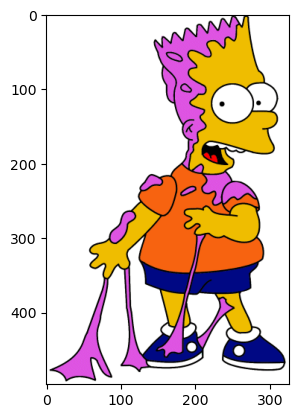

In [45]:
imagem = '/bart/bart1.bmp'
classificar_imagem(imagem)

Previsão:  1
{0: 'bart', 1: 'homer'}


'homer'

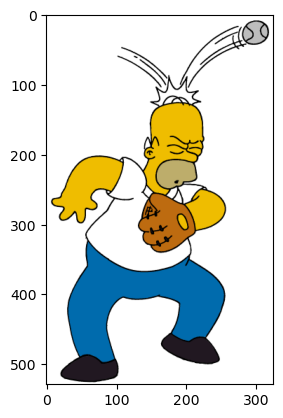

In [46]:
imagem = '/homer/homer7.bmp'
classificar_imagem(imagem)

Previsão:  1
{0: 'bart', 1: 'homer'}


'homer'

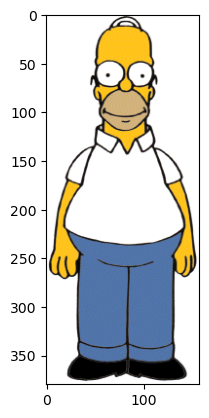

In [47]:
imagem = '/homer/homer10.bmp'
classificar_imagem(imagem)

Previsão:  0
{0: 'bart', 1: 'homer'}


'bart'

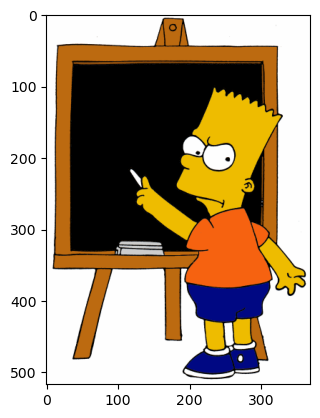

In [48]:
imagem = '/bart/bart10.bmp'
classificar_imagem(imagem)